In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv("data.csv")

In [3]:
data.columns

Index(['wandb_id', 'wandb_name', 'wandb_project', 'git_commit', 'tags',
       'condition', 'frame', 'network', 'delay_k', 'efference_length',
       'body_target_frame', 'fm_loss_weight', 'detach_prediction', 'seed',
       'latent_size', 'kl_weight', 'enc_hidden_sizes', 'dec_hidden_sizes',
       'critic_hidden_sizes', 'clip_length', 'actual_step', 'reward_mean',
       'reward_std', 'lifespan_mean', 'fm_pred_mse'],
      dtype='object')

In [5]:
data.condition.unique()

array(['current_efference', 'current_forward_model',
       'reference_efference', 'reference_forward_model'], dtype=object)

In [8]:
sns.set_theme()

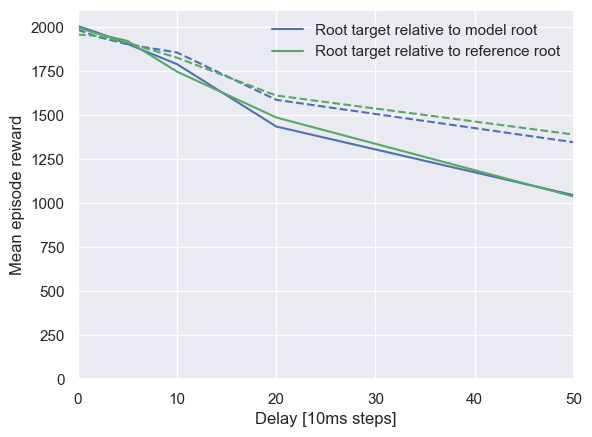

In [14]:
d = data[data.condition == "current_efference"]
plt.plot(d.delay_k, d.reward_mean, '-', color='C0', label="Root target relative to model root")
d = data[data.condition == "current_forward_model"]
plt.plot(d.delay_k, d.reward_mean, '--', color='C0')
d = data[data.condition == "reference_efference"]
plt.plot(d.delay_k, d.reward_mean, '-', color='C2', label="Root target relative to reference root")
d = data[data.condition == "reference_forward_model"]
plt.plot(d.delay_k, d.reward_mean, '--', color='C2')
plt.ylabel("Mean episode reward")
plt.xlabel("Delay [10ms steps]")
plt.xlim(0, 50)
plt.ylim(0, 2100)
plt.legend(frameon=False)
plt.savefig("figures/from_notebook.svg", bbox_inches="tight")